# Approximate HHL Reciprocal Rotation with Fractional-Binary Eigenvalue Encoding

This notebook implements a compressed approximation to the HHL reciprocal rotation.

We assume the eigenvalue register stores a fractional binary number

$$
\lambda(q)=0.q_1q_2\cdots q_n
=\frac{q_1}{2}+\frac{q_2}{4}+\cdots+\frac{q_n}{2^n}.
$$

Equivalently, if the bit string \(q_1q_2\cdots q_n\) represents the integer

$$
j = 2^{n-1}q_1+2^{n-2}q_2+\cdots+q_n,
$$

then

$$
\lambda_j = \frac{j}{2^n}.
$$

The HHL controlled rotation wants

$$
\sin \theta_j = \frac{C}{\lambda_j}.
$$

If we choose

$$
C = 2^{-n},
$$

then

$$
\frac{C}{\lambda_j}=\frac{1}{j}.
$$

Instead of implementing a full lookup table or higher-order controlled rotations, we approximate

$$
\theta(q)
\approx
\frac{\pi}{2}
\left(
x_0+\sum_{i=1}^n q_i x_i
\right).
$$

Circuit interpretation:

$$
R_y(\pi x_0)
$$

on the ancilla, followed by single-bit controlled rotations

$$
\text{controlled-}R_y(\pi x_i)
$$

controlled by \(q_i\).

In [1]:
import numpy as np
import pandas as pd

try:
    from scipy.optimize import least_squares
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("SciPy is not available. The notebook will use angle least-squares only.")

## 1. Utility functions

In [2]:
def bits_of_int(j, n):
    '''
    Return n-bit binary representation of integer j.

    Ordering:
        q1, q2, ..., qn
    from most significant bit to least significant bit.

    Example:
        bits_of_int(5, 3) -> [1, 0, 1]
    '''
    return np.array([(j >> (n - 1 - k)) & 1 for k in range(n)], dtype=float)


def bitstring_of_int(j, n):
    return "".join(str(int(b)) for b in bits_of_int(j, n))


def fractional_binary_lambda(j, n):
    '''
    Fractional binary eigenvalue:
        lambda_j = j / 2^n.
    '''
    return j / (2 ** n)


def build_design_matrix(n, use_offset=True):
    '''
    Build the feature matrix for the linear angle model.

    If use_offset=True:
        row = [1, q1, q2, ..., qn]

    If use_offset=False:
        row = [q1, q2, ..., qn]

    We exclude j=0 because lambda=0 is not invertible.
    '''
    js = np.arange(1, 2**n)
    Q = np.array([bits_of_int(j, n) for j in js], dtype=float)

    if use_offset:
        A = np.column_stack([np.ones(len(js)), Q])
    else:
        A = Q

    return js, Q, A

## 2. Fit the approximate HHL reciprocal rotation

We fit

$$
\theta(q)=\frac{\pi}{2}g(q),
$$

where

$$
g(q)=x_0+\sum_i q_i x_i.
$$

Two fitting modes are available:

### Angle fitting

$$
g(q)\approx \frac{2}{\pi}\arcsin\left(\frac{C}{\lambda(q)}\right).
$$

This is linear least squares.

### Amplitude fitting

$$
\sin\left(\frac{\pi}{2}g(q)\right)\approx \frac{C}{\lambda(q)}.
$$

This is nonlinear least squares, but it is usually better for HHL because the ancilla amplitude is what matters.

In [3]:
def fit_hhl_rotation(
    n,
    C=None,
    use_offset=True,
    fit_mode="amplitude",
    relative_error=False,
):
    '''
    Fit an approximate HHL reciprocal rotation.

    Parameters
    ----------
    n : int
        Number of QPE/eigenvalue qubits.

    C : float or None
        HHL scaling constant. If None, use C=2^{-n}.
        With fractional binary lambda_j=j/2^n, this gives C/lambda_j=1/j.

    use_offset : bool
        If True, fit x0 + q1*x1 + ... + qn*xn.
        If False, fit q1*x1 + ... + qn*xn.

    fit_mode : str
        "angle" or "amplitude".

    relative_error : bool
        If True, weight errors approximately by relative amplitude error.

    Returns
    -------
    dict
        Fitted coefficients and diagnostic arrays.
    '''
    if C is None:
        C = 2 ** (-n)

    js, Q, A = build_design_matrix(n, use_offset=use_offset)
    lambdas = js / (2 ** n)

    target_amp = C / lambdas

    if np.any(target_amp > 1 + 1e-12):
        raise ValueError(
            "Invalid C: some C/lambda_j > 1. "
            "Need C <= lambda_min = 2^{-n}."
        )

    target_g = (2 / np.pi) * np.arcsin(target_amp)

    if relative_error:
        weights = 1.0 / np.maximum(target_amp, 1e-15) ** 2
    else:
        weights = np.ones_like(target_amp)

    sqrt_w = np.sqrt(weights)

    # Initial guess from angle least squares.
    x_init = np.linalg.lstsq(
        A * sqrt_w[:, None],
        target_g * sqrt_w,
        rcond=None,
    )[0]

    if fit_mode == "angle":
        x_opt = x_init

    elif fit_mode == "amplitude":
        if not SCIPY_AVAILABLE:
            print("SciPy unavailable; falling back to angle fit.")
            x_opt = x_init
        else:
            def residual(x):
                g = A @ x
                approx_amp = np.sin((np.pi / 2) * g)
                return sqrt_w * (approx_amp - target_amp)

            sol = least_squares(
                residual,
                x_init,
                max_nfev=50000,
                xtol=1e-13,
                ftol=1e-13,
                gtol=1e-13,
            )
            x_opt = sol.x
    else:
        raise ValueError("fit_mode must be 'angle' or 'amplitude'.")

    g_approx = A @ x_opt
    theta_approx = (np.pi / 2) * g_approx
    ry_gate_angle = 2 * theta_approx

    exact_theta = np.arcsin(target_amp)
    exact_ry_gate_angle = 2 * exact_theta

    approx_amp = np.sin(theta_approx)
    abs_error = approx_amp - target_amp
    rel_error = abs_error / target_amp

    bitstrings = [bitstring_of_int(j, n) for j in js]

    table = pd.DataFrame({
        "j": js,
        "bits": bitstrings,
        "lambda": lambdas,
        "target_amp_C_over_lambda": target_amp,
        "approx_amp_sin_theta": approx_amp,
        "abs_error": abs_error,
        "rel_error": rel_error,
        "exact_theta": exact_theta,
        "approx_theta": theta_approx,
        "Ry_angle_exact": exact_ry_gate_angle,
        "Ry_angle_approx": ry_gate_angle,
    })

    return {
        "n": n,
        "C": C,
        "use_offset": use_offset,
        "fit_mode": fit_mode,
        "relative_error": relative_error,
        "coefficients": x_opt,
        "js": js,
        "bitstrings": bitstrings,
        "lambdas": lambdas,
        "target_amp": target_amp,
        "approx_amp": approx_amp,
        "exact_theta": exact_theta,
        "theta_approx": theta_approx,
        "exact_ry_gate_angle": exact_ry_gate_angle,
        "ry_gate_angle": ry_gate_angle,
        "abs_error": abs_error,
        "rel_error": rel_error,
        "max_abs_error": np.max(np.abs(abs_error)),
        "rmse": np.sqrt(np.mean(abs_error**2)),
        "max_rel_error": np.max(np.abs(rel_error)),
        "table": table,
    }


def print_coefficients(fit):
    coeffs = fit["coefficients"]
    n = fit["n"]

    print("====================================")
    print("Fitted approximate HHL rotation")
    print("====================================")
    print(f"n = {n}")
    print(f"C = {fit['C']}")
    print(f"fit_mode = {fit['fit_mode']}")
    print(f"use_offset = {fit['use_offset']}")
    print(f"relative_error = {fit['relative_error']}")
    print()

    if fit["use_offset"]:
        print(f"x0 = {coeffs[0]: .12f}")
        for i in range(n):
            print(f"x{i+1} = {coeffs[i+1]: .12f}")
    else:
        for i in range(n):
            print(f"x{i+1} = {coeffs[i]: .12f}")

    print()
    print("Circuit rotation angles:")
    print("The actual gate angles are Ry(pi*x_i).")
    print()

    if fit["use_offset"]:
        print(f"Uncontrolled ancilla rotation: Ry({np.pi * coeffs[0]: .12f})")
        for i in range(n):
            print(f"Controlled by q{i+1}: Ry({np.pi * coeffs[i+1]: .12f})")
    else:
        for i in range(n):
            print(f"Controlled by q{i+1}: Ry({np.pi * coeffs[i]: .12f})")

    print()
    print("Errors:")
    print(f"max_abs_error = {fit['max_abs_error']:.6e}")
    print(f"rmse          = {fit['rmse']:.6e}")
    print(f"max_rel_error = {fit['max_rel_error']:.6e}")

## 3. Example: fit for \(n=3\)

For \(n=3\),

$$
\lambda_j = \frac{j}{8}, \qquad j=1,\dots,7.
$$

Using \(C=2^{-3}=1/8\), the target amplitudes are

$$
\frac{C}{\lambda_j}=\frac{1}{j}.
$$

In [4]:
n = 3

fit = fit_hhl_rotation(
    n=n,
    C=None,                  # default C = 2^{-n}
    use_offset=True,
    fit_mode="amplitude",    # recommended for HHL
    relative_error=False,
)

print_coefficients(fit)
fit["table"]

Fitted approximate HHL rotation
n = 3
C = 0.125
fit_mode = amplitude
use_offset = True
relative_error = False

x0 =  0.526206735340
x1 = -0.313263837794
x2 = -0.170374502296
x3 = -0.006729659723

Circuit rotation angles:
The actual gate angles are Ry(pi*x_i).

Uncontrolled ancilla rotation: Ry( 1.653127214013)
Controlled by q1: Ry(-0.984147371450)
Controlled by q2: Ry(-0.535247284773)
Controlled by q3: Ry(-0.021141849548)

Errors:
max_abs_error = 2.715939e-01
rmse          = 1.452086e-01
max_rel_error = 6.061406e-01


,j,bits,lambda,target_amp_C_over_lambda,approx_amp_sin_theta,abs_error,rel_error,exact_theta,approx_theta,Ry_angle_exact,Ry_angle_approx
0,1,001,0.125,1.000000,0.728406,-0.271594,-0.271594,1.570796,0.815993,3.141593,1.631985
1,2,010,0.250,0.500000,0.530288,0.030288,0.060576,0.523599,0.558940,1.047198,1.117880
2,3,011,0.375,0.333333,0.521296,0.187963,0.563888,0.339837,0.548369,0.679674,1.096738
3,4,100,0.500,0.250000,0.328287,0.078287,0.313150,0.252680,0.334490,0.505361,0.668980
4,5,101,0.625,0.200000,0.318284,0.118284,0.591421,0.201358,0.323919,0.402716,0.647838
5,6,110,0.750,0.166667,0.066816,-0.099850,-0.599101,0.167448,0.066866,0.334896,0.133733
6,7,111,0.875,0.142857,0.056266,-0.086592,-0.606141,0.143348,0.056295,0.286695,0.112591


## 4. Simple HHL-style demo

Here we do **not** build the full QPE circuit. Instead, we assume QPE has already produced the correct eigenvalue labels.

We choose a diagonal matrix

$$
A=\mathrm{diag}(\lambda_1,\lambda_2,\ldots),
$$

where each eigenvalue is encoded by a fractional-binary label

$$
\lambda_j = \frac{j}{2^n}.
$$

The exact HHL solution state is

$$
|x\rangle \propto A^{-1}|b\rangle.
$$

The approximate HHL postselected state is

$$
|x_{\rm approx}\rangle
\propto
\sum_j \beta_j \sin(\theta_{\rm approx}(j)) |u_j\rangle.
$$

If the approximation is good, then

$$
\sin(\theta_{\rm approx}(j)) \approx \frac{C}{\lambda_j},
$$

so the postselected state approximates \(A^{-1}|b\rangle\).

In [5]:
def normalize(v):
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm < 1e-15:
        raise ValueError("Cannot normalize zero vector.")
    return v / norm


def approximate_amplitude_from_fit(j, fit):
    '''
    Compute sin(theta_approx(j)) using the fitted linear bit-angle model.
    '''
    n = fit["n"]
    coeffs = fit["coefficients"]
    q = bits_of_int(j, n)

    if fit["use_offset"]:
        g = coeffs[0] + np.dot(q, coeffs[1:])
    else:
        g = np.dot(q, coeffs)

    theta = (np.pi / 2) * g
    return np.sin(theta), theta


def simple_hhl_demo(
    n=3,
    eigenvalue_labels=None,
    b=None,
    C=None,
    fit_mode="amplitude",
    relative_error=False,
):
    '''
    Simple HHL demo using a diagonal matrix.

    Parameters
    ----------
    n : int
        Number of eigenvalue bits.

    eigenvalue_labels : list[int]
        Integer labels j. The eigenvalues are lambda_j = j / 2^n.

    b : array-like
        Input state amplitudes in the eigenbasis.

    C : float or None
        HHL scaling. If None, use C = 2^{-n}.

    Returns
    -------
    dict
        Demo data and fidelity.
    '''
    if C is None:
        C = 2 ** (-n)

    if eigenvalue_labels is None:
        if n >= 3:
            eigenvalue_labels = [1, 2, 4, 2**n - 1]
        else:
            eigenvalue_labels = list(range(1, 2**n))

    eigenvalue_labels = np.array(eigenvalue_labels, dtype=int)
    lambdas = eigenvalue_labels / (2**n)

    d = len(eigenvalue_labels)

    if b is None:
        b = np.ones(d)
    b = normalize(b)

    fit = fit_hhl_rotation(
        n=n,
        C=C,
        use_offset=True,
        fit_mode=fit_mode,
        relative_error=relative_error,
    )

    approx_amps = []
    approx_thetas = []

    for j in eigenvalue_labels:
        amp, theta = approximate_amplitude_from_fit(j, fit)
        approx_amps.append(amp)
        approx_thetas.append(theta)

    approx_amps = np.array(approx_amps)
    approx_thetas = np.array(approx_thetas)

    # Exact normalized solution |x> proportional to A^{-1}|b>.
    x_exact = normalize(b / lambdas)

    # Ideal HHL postselected state.
    ideal_hhl_amps = C / lambdas
    x_ideal_hhl = normalize(b * ideal_hhl_amps)

    # Approximate HHL postselected state.
    x_approx_hhl = normalize(b * approx_amps)

    fidelity = abs(np.vdot(x_exact, x_approx_hhl)) ** 2

    postselection_prob_ideal = np.sum(np.abs(b)**2 * ideal_hhl_amps**2)
    postselection_prob_approx = np.sum(np.abs(b)**2 * approx_amps**2)

    table = pd.DataFrame({
        "label_j": eigenvalue_labels,
        "bits": [bitstring_of_int(j, n) for j in eigenvalue_labels],
        "lambda": lambdas,
        "b_amplitude": b,
        "target_C_over_lambda": ideal_hhl_amps,
        "approx_sin_theta": approx_amps,
        "approx_theta": approx_thetas,
        "exact_x_state": x_exact,
        "ideal_hhl_state": x_ideal_hhl,
        "approx_hhl_state": x_approx_hhl,
    })

    return {
        "fit": fit,
        "A": np.diag(lambdas),
        "b": b,
        "lambdas": lambdas,
        "eigenvalue_labels": eigenvalue_labels,
        "x_exact": x_exact,
        "x_ideal_hhl": x_ideal_hhl,
        "x_approx_hhl": x_approx_hhl,
        "fidelity": fidelity,
        "postselection_prob_ideal": postselection_prob_ideal,
        "postselection_prob_approx": postselection_prob_approx,
        "table": table,
    }

## 5. Run the simple HHL demo

For \(n=3\), choose labels

$$
j = 1,2,4,7,
$$

so the diagonal matrix has eigenvalues

$$
\lambda = \frac18,\frac28,\frac48,\frac78.
$$

In [6]:
demo = simple_hhl_demo(
    n=3,
    eigenvalue_labels=[1, 2, 4, 7],
    b=[1, 1, 1, 1],
    C=None,
    fit_mode="amplitude",
    relative_error=False,
)

print("Diagonal matrix A:")
print(demo["A"])
print()

print("Input state |b>:")
print(demo["b"])
print()

print("Exact normalized solution |x> proportional to A^{-1}|b>:")
print(demo["x_exact"])
print()

print("Approximate HHL postselected state:")
print(demo["x_approx_hhl"])
print()

print(f"Fidelity = {demo['fidelity']:.12f}")
print(f"Ideal postselection probability  = {demo['postselection_prob_ideal']:.12f}")
print(f"Approx postselection probability = {demo['postselection_prob_approx']:.12f}")

demo["table"]

Diagonal matrix A:
[[0.125 0.    0.    0.   ]
 [0.    0.25  0.    0.   ]
 [0.    0.    0.5   0.   ]
 [0.    0.    0.    0.875]]

Input state |b>:
[0.5 0.5 0.5 0.5]

Exact normalized solution |x> proportional to A^{-1}|b>:
[0.86616351 0.43308176 0.21654088 0.12373764]

Approximate HHL postselected state:
[0.75829612 0.55204806 0.34175863 0.05857448]

Fidelity = 0.954808365973
Ideal postselection probability  = 0.333227040816
Approx postselection probability = 0.230679749876


,label_j,bits,lambda,b_amplitude,target_C_over_lambda,approx_sin_theta,approx_theta,exact_x_state,ideal_hhl_state,approx_hhl_state
0,1,001,0.125,0.5,1.000000,0.728406,0.815993,0.866164,0.866164,0.758296
1,2,010,0.250,0.5,0.500000,0.530288,0.558940,0.433082,0.433082,0.552048
2,4,100,0.500,0.5,0.250000,0.328287,0.334490,0.216541,0.216541,0.341759
3,7,111,0.875,0.5,0.142857,0.056266,0.056295,0.123738,0.123738,0.058574


## 6. Try a larger eigenvalue register

Increase `n` below. The number of fit points is \(2^n-1\), while the number of parameters is only \(n+1\), so this is a strongly compressed approximation.

You can compare:

- `fit_mode="angle"`
- `fit_mode="amplitude"`
- `relative_error=True`
- `relative_error=False`

In [7]:
n = 4

fit4 = fit_hhl_rotation(
    n=n,
    C=None,
    use_offset=True,
    fit_mode="amplitude",
    relative_error=False,
)

print_coefficients(fit4)
fit4["table"].head(15)

Fitted approximate HHL rotation
n = 4
C = 0.0625
fit_mode = amplitude
use_offset = True
relative_error = False

x0 =  0.348965171566
x1 = -0.193124673357
x2 = -0.137238100268
x3 = -0.069802895513
x4 =  0.013295767775

Circuit rotation angles:
The actual gate angles are Ry(pi*x_i).

Uncontrolled ancilla rotation: Ry( 1.096306419349)
Controlled by q1: Ry(-0.606719055046)
Controlled by q2: Ry(-0.431146207594)
Controlled by q3: Ry(-0.219292263742)
Controlled by q4: Ry( 0.041769886365)

Errors:
max_abs_error = 4.611780e-01
rmse          = 1.538505e-01
max_rel_error = 2.124744e+00


,j,bits,lambda,target_amp_C_over_lambda,approx_amp_sin_theta,abs_error,rel_error,exact_theta,approx_theta,Ry_angle_exact,Ry_angle_approx
0,1,0001,0.0625,1.000000,0.538822,-0.461178,-0.461178,1.570796,0.569038,3.141593,1.138076
1,2,0010,0.1250,0.500000,0.424588,-0.075412,-0.150823,0.523599,0.438507,1.047198,0.877014
2,3,0011,0.1875,0.333333,0.443403,0.110070,0.330210,0.339837,0.459392,0.679674,0.918784
3,4,0100,0.2500,0.250000,0.326483,0.076483,0.305931,0.252680,0.332580,0.505361,0.665160
4,5,0101,0.3125,0.200000,0.346151,0.146151,0.730754,0.201358,0.353465,0.402716,0.706930
5,6,0110,0.3750,0.166667,0.221092,0.054425,0.326552,0.167448,0.222934,0.334896,0.445868
6,7,0111,0.4375,0.142857,0.241410,0.098553,0.689872,0.143348,0.243819,0.286695,0.487638
7,8,1000,0.5000,0.125000,0.242356,0.117356,0.938849,0.125328,0.244794,0.250656,0.489587
8,9,1001,0.5625,0.111111,0.262564,0.151453,1.363077,0.111341,0.265679,0.222682,0.531357
9,10,1010,0.6250,0.100000,0.134737,0.034737,0.347365,0.100167,0.135148,0.200335,0.270295


## 8. Visualization: what are we comparing?

The approximation problem is:

$$
\text{exact target amplitude}=\frac{C}{\lambda_j}
$$

versus

$$
\text{implemented amplitude}
=
\sin\left[
\frac{\pi}{2}
\left(
x_0+\sum_i q_i x_i
\right)
\right].
$$

So the key visual comparisons are:

1. exact amplitude \(C/\lambda_j\) vs approximate amplitude,
2. exact angle \(\theta_j=\arcsin(C/\lambda_j)\) vs approximate angle,
3. approximation error,
4. exact HHL solution state vs approximate postselected HHL state.

In [8]:
import matplotlib.pyplot as plt

def plot_amplitude_comparison(fit):
    table = fit["table"]

    plt.figure(figsize=(8, 5))
    plt.plot(table["j"], table["target_amp_C_over_lambda"], marker="o", label="Exact target C/lambda")
    plt.plot(table["j"], table["approx_amp_sin_theta"], marker="x", label="Approx sin(theta)")
    plt.xlabel("Eigenvalue label j")
    plt.ylabel("Ancilla |1> amplitude")
    plt.title("HHL reciprocal amplitude: exact vs compressed approximation")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_angle_comparison(fit):
    table = fit["table"]

    plt.figure(figsize=(8, 5))
    plt.plot(table["j"], table["exact_theta"], marker="o", label="Exact theta")
    plt.plot(table["j"], table["approx_theta"], marker="x", label="Approx theta")
    plt.xlabel("Eigenvalue label j")
    plt.ylabel("Angle theta")
    plt.title("Rotation angle: exact vs compressed approximation")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_error(fit):
    table = fit["table"]

    plt.figure(figsize=(8, 5))
    plt.axhline(0, linewidth=1)
    plt.plot(table["j"], table["abs_error"], marker="o", label="Approx - exact")
    plt.xlabel("Eigenvalue label j")
    plt.ylabel("Amplitude error")
    plt.title("Approximation error in HHL reciprocal amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_hhl_state_comparison(demo):
    labels = [str(j) for j in demo["eigenvalue_labels"]]

    plt.figure(figsize=(8, 5))
    plt.plot(labels, demo["x_exact"], marker="o", label="Exact normalized A^{-1}|b>")
    plt.plot(labels, demo["x_approx_hhl"], marker="x", label="Approx HHL postselected state")
    plt.xlabel("Eigenvalue label j")
    plt.ylabel("State amplitude")
    plt.title("HHL output state: exact vs approximate")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_all_visualizations(fit, demo):
    plot_amplitude_comparison(fit)
    plot_angle_comparison(fit)
    plot_error(fit)
    plot_hhl_state_comparison(demo)

### Run visualization for the \(n=3\) example

This uses the fitted coefficients from the previous cells and compares the compressed approximation against the exact HHL reciprocal rotation.

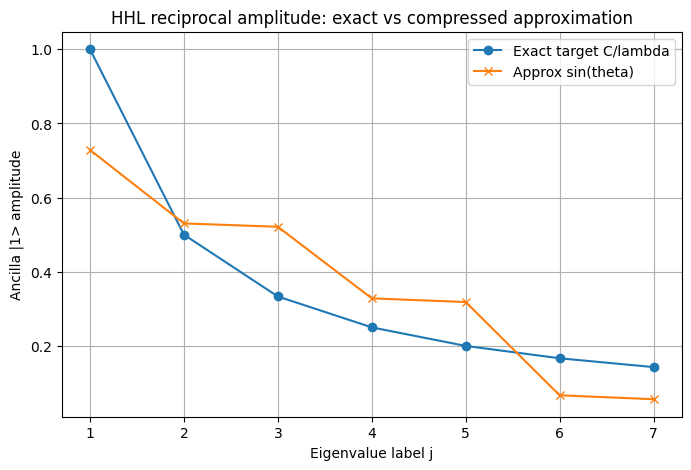

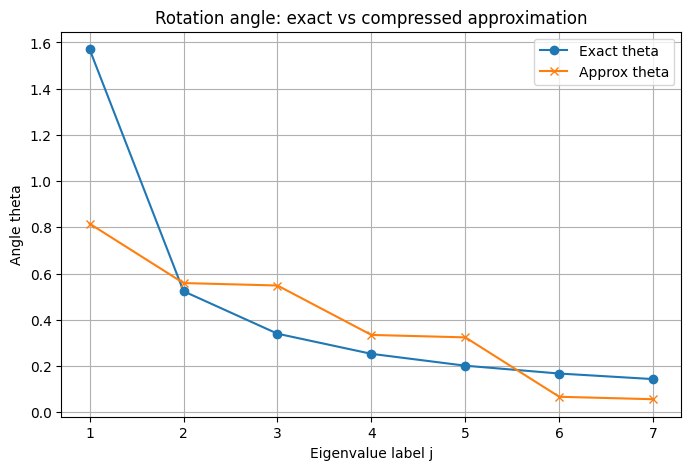

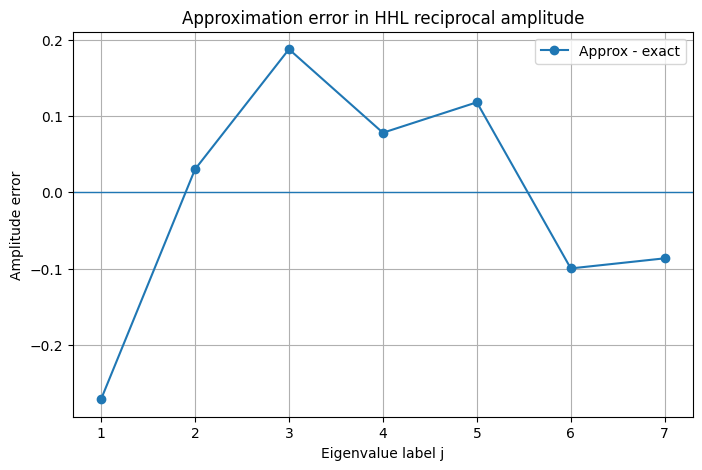

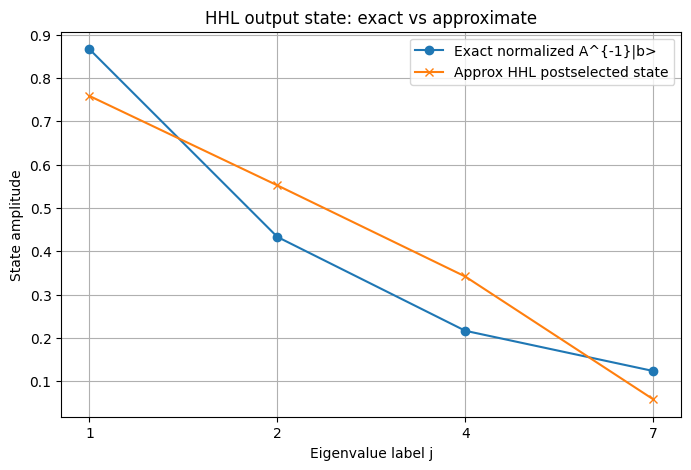

In [9]:
plot_all_visualizations(fit, demo)

## 9. Conceptual picture

This picture summarizes the approximation.

$$
q_1q_2\cdots q_n
\quad\Longrightarrow\quad
\lambda_j=\frac{j}{2^n}
\quad\Longrightarrow\quad
\frac{C}{\lambda_j}
$$

The exact implementation would apply a different rotation for each \(j\).  
The compressed implementation uses only one offset plus \(n\) single-bit controlled rotations:

$$
\theta(q)
\approx
\frac{\pi}{2}
\left(
x_0+\sum_i q_i x_i
\right).
$$

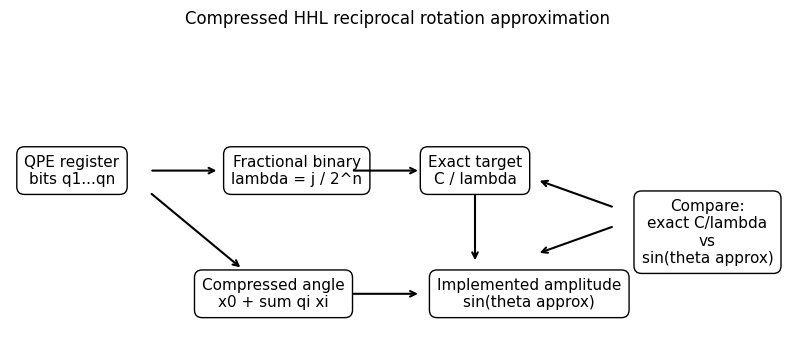

In [36]:
def draw_conceptual_diagram():
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis("off")

    boxes = [
        (0.08, 0.55, "QPE register\nbits q1...qn"),
        (0.37, 0.55, "Fractional binary\nlambda = j / 2^n"),
        (0.60, 0.55, "Exact target\nC / lambda"),
        (0.34, 0.15, "Compressed angle\nx0 + sum qi xi"),
        (0.67, 0.15, "Implemented amplitude\nsin(theta approx)"),
    ]

    for x, y, text in boxes:
        ax.text(
            x, y, text,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.5", fill=False),
            fontsize=11,
        )

    arrows = [
        ((0.18, 0.55), (0.27, 0.55)),
        ((0.44, 0.55), (0.53, 0.55)),
        ((0.18, 0.48), (0.30, 0.23)),
        ((0.44, 0.15), (0.53, 0.15)),
        ((0.60, 0.48), (0.60, 0.25)),
    ]

    for start, end in arrows:
        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", lw=1.5),
        )

    ax.text(
        0.90,
        0.35,
        "Compare:\nexact C/lambda\nvs\nsin(theta approx)",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.5", fill=False),
        fontsize=11,
    )

    ax.annotate(
        "",
        xy=(0.68, 0.52),
        xytext=(0.78, 0.43),
        arrowprops=dict(arrowstyle="->", lw=1.5),
    )
    ax.annotate(
        "",
        xy=(0.68, 0.28),
        xytext=(0.78, 0.37),
        arrowprops=dict(arrowstyle="->", lw=1.5),
    )

    plt.title("Compressed HHL reciprocal rotation approximation")
    plt.show()


draw_conceptual_diagram()

## 7. Notes

This approximation is cheap because it uses only

$$
1+n
$$

rotations:

- one unconditional \(R_y(\pi x_0)\),
- \(n\) single-controlled \(R_y(\pi x_i)\).

It does **not** require higher-order controlled rotations such as \(q_iq_j\), nor a full lookup table.

However, because the reciprocal function is nonlinear in the binary bits, the approximation error does not vanish unless you add more expressive terms or use a QROM/lookup-table rotation.